# Exploratory data analysis: BC–WA hourly PM2.5 dataset

EDA of `data/BCWA_AirNow_2y.npy`: 115 reference monitors (54 BC, 61 WA) with ERA5 weather, hourly from 1 Oct 2024 to 30 Sep 2026.

**Conventions**
- Statistics on PM2.5 use **measured values only** (`BCWA_AirNow_2y_observed.npy`), not gap-filled ones, the same rule `benchmark.py` scores by. Section 3 compares filled and measured values directly.
- Splits are read from `config.yaml` (dataset 1).
- Time is UTC unless stated. Daily and weekly cycles use local time (`America/Vancouver`).
- 35.5 µg/m³ is used as the high-pollution threshold: the US AQI breakpoint for *Unhealthy for Sensitive Groups*.
- Figures are saved to `figures/eda/` as PNG and PDF, in journal style (sized for 3.5 in / 7.2 in columns, no titles: put those in the captions).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

DATA = Path('data')
FIG = Path('figures/eda')
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 140, 'display.max_columns', 30)

# Journal figure style: no grid, no top/right spines, outward ticks, serif text, and
# widths matching a two-column page (fonts stay legible at print size). Titles go in
# the LaTeX captions; multi-panel figures get (a), (b), ... labels instead.
sns.set_theme(style='ticks', context='paper')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'STIXGeneral', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8, 'axes.titleweight': 'normal',
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7, 'legend.title_fontsize': 7,
    'axes.grid': False, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.6, 'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 3, 'ytick.major.size': 3, 'xtick.direction': 'out', 'ytick.direction': 'out',
    'lines.linewidth': 1.0, 'lines.markersize': 3, 'patch.linewidth': 0.5, 'legend.frameon': False,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
COL1, COL2 = 3.5, 7.2                        # single- / double-column width (inches)
PM_UNIT = r'$\mu$g m$^{-3}$'
PM_LABEL = rf'PM$_{{2.5}}$ ({PM_UNIT})'
SEASON_STYLE = {'DJF': ('k', '-', 'o'), 'MAM': ('0.55', '-', 's'), 'JJA': ('k', '--', '^'), 'SON': ('0.55', '--', 'D')}

FEATURES = ['temperature', 'relative_humidity', 'rain', 'wind_speed10', 'wind_direction10', 'pm25']
UNITS = {'temperature': '°C', 'relative_humidity': '%', 'rain': 'mm', 'wind_speed10': 'm/s',
         'wind_direction10': '°', 'pm25': 'µg/m³'}
HIGH = 35.5  # µg/m³
SPLIT_STYLE = {'train': ('k', '-'), 'val': ('k', '--'), 'test': ('k', ':')}
SPLIT_NAME = {'train': 'Train', 'val': 'Validation', 'test': 'Test'}
SEASON = {12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM',
          6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'}


def savefig(name, fig=None):
    # PNG for quick viewing, PDF (vector, embedded fonts) for the paper
    fig = fig or plt.gcf()
    fig.savefig(FIG / f'{name}.png')
    fig.savefig(FIG / f'{name}.pdf')


def panel_labels(axes, x=-0.14, y=1.02, names=None):
    # mark subplots (a), (b), ... at the top-left corner, optionally with a short name
    for i, ax in enumerate(np.ravel(axes)):
        label = f'({chr(97 + i)})' + (f' {names[i]}' if names else '')
        ax.text(x, y, label, transform=ax.transAxes, fontsize=8, fontweight='bold', va='bottom', ha='left')


X = np.load(DATA / 'BCWA_AirNow_2y.npy')                 # [T, N, 6]
OBS = np.load(DATA / 'BCWA_AirNow_2y_observed.npy')      # [T, N] True = measured PM2.5
sites = pd.read_csv(DATA / 'BCWA_AirNow_2y_sites.csv', dtype={'aqsid': str})
monthly = pd.read_csv(DATA / 'BCWA_AirNow_2y_monthly.csv', index_col=0)
T, N, F = X.shape

cfg = yaml.safe_load(open('config.yaml'))['dataset'][1]
ts = lambda k: pd.Timestamp(*cfg[k][0], tz='UTC')
time = pd.date_range(ts('data_start'), periods=T, freq='h')
SPLITS = {s: (ts(f'{s}_start'), ts(f'{s}_end')) for s in ['train', 'val', 'test']}
split = pd.Series('', index=time)
for s, (a, b) in SPLITS.items():
    split[a:b] = s

pm = pd.DataFrame(X[..., 5], index=time, columns=sites.node)   # gap-filled (model input)
pm_obs = pm.where(OBS)                                          # measured only (scored)
met = {f: pd.DataFrame(X[..., i], index=time, columns=sites.node) for i, f in enumerate(FEATURES[:5])}
print(f'{T} hours x {N} stations x {F} features, {time[0]:%Y-%m-%d} .. {time[-1]:%Y-%m-%d %H:%M} UTC')
print(split.value_counts().reindex(SPLITS))

17520 hours x 115 stations x 6 features, 2024-10-01 .. 2026-09-30 23:00 UTC
train    10968
val       2160
test      4392
Name: count, dtype: int64


## 1. Overview: stations and features

In [2]:
display(sites.groupby(['country', 'region', 'agency']).size().rename('stations').to_frame())
display(sites[['completeness', 'longest_gap_h', 'elevation']].describe().round(2).T)

stations
country region agency                                            
CA      BC     British Columbia Ministry of Environment        34
               Metro Vancouver                                 20
US      WA     Spokane Regional Clean Air Agency                1
               Washington Department of Ecology                60

,count,mean,std,min,25%,50%,75%,max
completeness,115.0,0.96,0.04,0.85,0.94,0.97,0.99,1.0
longest_gap_h,115.0,280.81,345.51,1.00,67.50,147.00,370.00,1646.0
elevation,115.0,248.88,281.16,0.00,28.00,104.00,466.00,1335.0


In [3]:
rows = []
for i, f in enumerate(FEATURES):
    v = X[..., i][OBS] if f == 'pm25' else X[..., i].ravel()
    rows.append({'feature': f, 'unit': UNITS[f], 'mean': v.mean(), 'std': v.std(), 'min': v.min(),
                 'p01': np.percentile(v, 1), 'median': np.median(v), 'p99': np.percentile(v, 99), 'max': v.max()})
pd.DataFrame(rows).set_index('feature').round(2)

,unit,mean,std,min,p01,median,p99,max
feature,,,,,,,,
temperature,°C,10.180000,8.530000,-38.799999,-11.70,9.90,30.9,42.799999
relative_humidity,%,73.290001,20.420000,2.000000,18.00,79.00,99.0,100.000000
rain,mm,0.150000,0.440000,0.000000,0.00,0.00,2.2,10.700000
wind_speed10,m/s,2.120000,1.340000,0.000000,0.25,1.82,6.7,16.690001
wind_direction10,°,182.220001,93.440002,0.000000,7.00,190.00,356.0,360.000000
pm25,µg/m³,6.040000,8.790000,0.000000,0.00,4.00,37.0,687.000000


## 2. Station network
Colour shows each station's mean measured PM2.5. The longitude axis is scaled by cos(latitude), so distances look right.

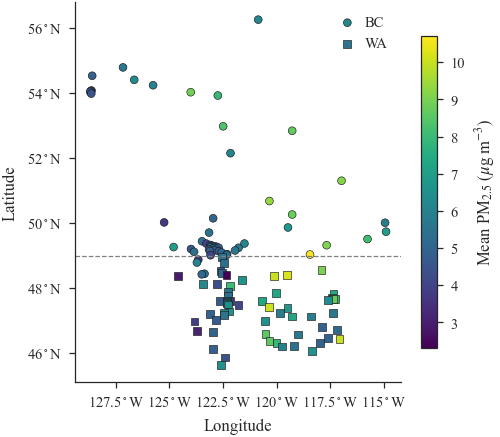

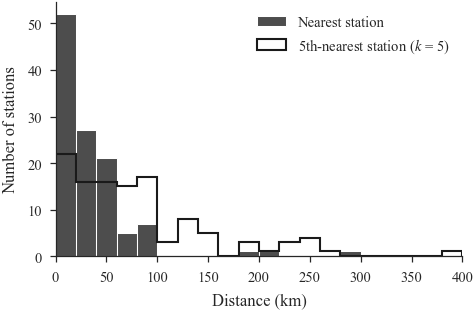

,count,mean,std,min,25%,50%,75%,max
nn1_km,115.0,33.9,40.4,1.7,8.9,26.5,44.5,285.5
nn5_km,115.0,82.0,71.3,8.8,28.0,64.3,101.1,393.0


In [4]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

lat, lon = sites.lat.values, sites.lon.values
D = haversine(lat[:, None], lon[:, None], lat[None], lon[None])          # [N, N] km
Dn = np.sort(np.where(np.eye(N, dtype=bool), np.inf, D), axis=1)
sites['mean_pm'] = pm_obs.mean().values
sites['nn1_km'], sites['nn5_km'] = Dn[:, 0], Dn[:, 4]

# (a) station map -> 01a_station_map
fig, ax = plt.subplots(figsize=(COL1, 3.6))
for c, m in [('CA', 'o'), ('US', 's')]:
    s = sites[sites.country == c]
    sc = ax.scatter(s.lon, s.lat, c=s.mean_pm, cmap='viridis', marker=m, s=14, edgecolor='k', lw=0.3,
                    vmin=sites.mean_pm.min(), vmax=sites.mean_pm.max(), label={'CA': 'BC', 'US': 'WA'}[c])
ax.axhline(49, color='0.5', ls='--', lw=0.6)     # Canada-US border; explained in the caption
ax.set_aspect(1 / np.cos(np.radians(lat.mean())))
ax.set(xlabel='Longitude', ylabel='Latitude')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: rf'{-v:g}$^\circ$W'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: rf'{v:g}$^\circ$N'))
leg = ax.legend(loc='upper right', handletextpad=0.2)
for h in leg.legend_handles:
    h.set_facecolor('0.6')
cb = fig.colorbar(sc, ax=ax, shrink=0.75, label=f'Mean {PM_LABEL}')
cb.outline.set_linewidth(0.6)
savefig('01a_station_map', fig); plt.show()

# (b) neighbour distances -> 01b_station_map
fig, ax = plt.subplots(figsize=(COL1, 2.2))
bins = np.arange(0, 420, 20)
ax.hist(sites.nn1_km, bins=bins, color='0.3', label='Nearest station')
ax.hist(sites.nn5_km, bins=bins, histtype='step', color='k', lw=1.0, label='5th-nearest station ($k$ = 5)')
ax.set(xlabel='Distance (km)', ylabel='Number of stations', xlim=(0, 400))
ax.legend()
savefig('01b_station_map', fig); plt.show()
sites[['nn1_km', 'nn5_km']].describe().round(1).T

## 3. Missing data and gap filling
Gap-filled values go into the models' inputs but are never scored. This section shows where gaps occur, how long they last, and whether filled values look like measured ones.

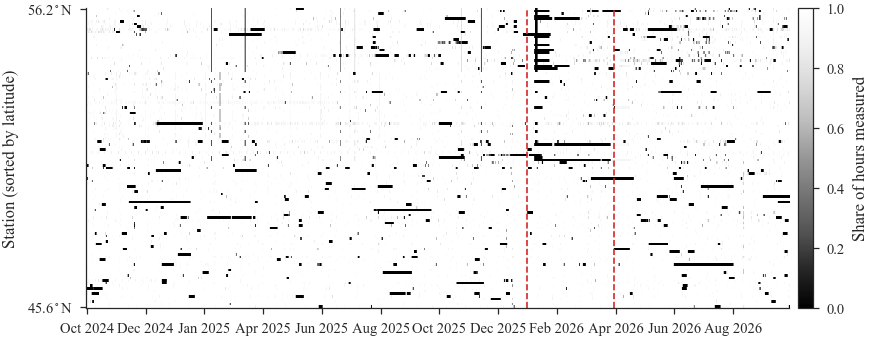

measured share per split:
train    0.9659
val      0.9338
test     0.9588
dtype: float64
stations with >5% missing in TEST: 26


In [5]:
order = np.argsort(-lat)                                   # north at the top
daily_obs = pd.DataFrame(OBS, index=time).resample('D').mean().iloc[:, order]
fig, ax = plt.subplots(figsize=(COL2, 2.6))
im = ax.imshow(daily_obs.T.values, aspect='auto', cmap='Greys_r', vmin=0, vmax=1, interpolation='nearest',
               rasterized=True)
ticks = np.arange(0, len(daily_obs), 61)
ax.set_xticks(ticks, daily_obs.index[ticks].strftime('%b %Y'))
ax.set_yticks([0, N - 1], [rf'{lat[order[0]]:.1f}$^\circ$N', rf'{lat[order[-1]]:.1f}$^\circ$N'])
ax.set(ylabel='Station (sorted by latitude)')
cb = fig.colorbar(im, ax=ax, pad=0.01, label='Share of hours measured')
cb.outline.set_linewidth(0.6)
for s, (a, b) in SPLITS.items():
    if s != 'train':
        ax.axvline(daily_obs.index.get_indexer([a.normalize()])[0], color='tab:red', lw=0.8, ls='--')
savefig('02_missingness'); plt.show()

print('measured share per split:')
print(pd.DataFrame(OBS, index=time).groupby(split).mean().mean(axis=1).reindex(SPLITS).round(4))
print('stations with >5% missing in TEST:',
      int((pd.DataFrame(OBS, index=time)[split == 'test'].mean() < 0.95).sum()))

7047 gaps; median 1 h; 84.9% are <= 6 h (linear fill), holding 11.8% of missing hours


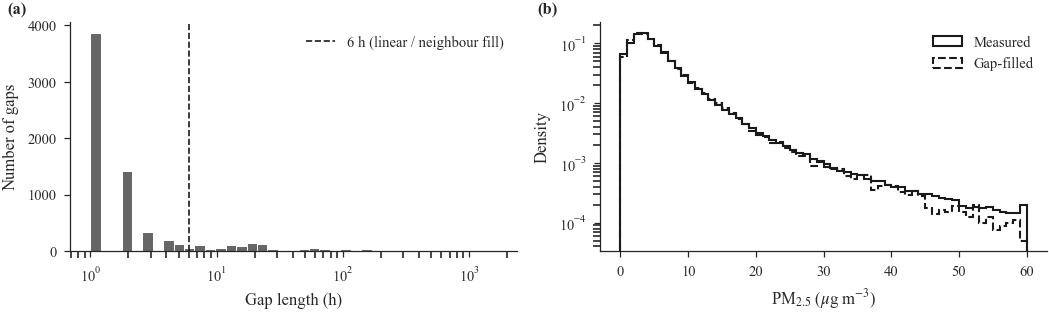

,count,mean,std,min,50%,90%,99%,max
measured,1934530.0,6.04,8.79,0.0,4.00,11.60,37.00,687.0
gap-filled,80270.0,5.97,7.93,0.0,4.23,11.67,32.43,565.5


In [6]:
gaps = []
for j in range(N):
    m = np.r_[False, ~OBS[:, j], False].astype(int)
    starts, ends = np.where(np.diff(m) == 1)[0], np.where(np.diff(m) == -1)[0]
    gaps += list(ends - starts)
gaps = np.array(gaps)
print(f'{len(gaps)} gaps; median {np.median(gaps):.0f} h; '
      f'{(gaps <= 6).mean():.1%} are <= 6 h (linear fill), holding {gaps[gaps <= 6].sum() / gaps.sum():.1%} of missing hours')

filled = X[..., 5][~OBS]
measured = X[..., 5][OBS]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(COL2, 2.3))
a1.hist(gaps, bins=np.logspace(0, np.log10(gaps.max() + 1), 40), color='0.4')
a1.set(xscale='log', xlabel='Gap length (h)', ylabel='Number of gaps')
a1.axvline(6, color='k', ls='--', lw=0.8, label='6 h (linear / neighbour fill)'); a1.legend()
bins = np.linspace(0, 60, 61)
a2.hist(measured, bins=bins, density=True, histtype='step', color='k', lw=1.0, label='Measured')
a2.hist(filled, bins=bins, density=True, histtype='step', color='k', ls='--', lw=1.0, label='Gap-filled')
a2.set(yscale='log', xlabel=PM_LABEL, ylabel='Density'); a2.legend()
panel_labels([a1, a2])
plt.tight_layout(); savefig('03_gaps'); plt.show()
pd.DataFrame({'measured': pd.Series(measured).describe(percentiles=[.5, .9, .99]),
              'gap-filled': pd.Series(filled).describe(percentiles=[.5, .9, .99])}).round(2).T

## 4. PM2.5 distribution and the shift between splits
The test split (Apr–Sep 2026) includes the summer wildfire-smoke season. Validation (Jan–Mar) covers winter only. Models are chosen on validation and scored on test, so differences between the splits matter.

,count,mean,std,min,25%,50%,75%,90%,99%,99.9%,max,share > 35.5,share < 1
split,,,,,,,,,,,,,
train,1218311.0,5.780,6.720,0.0,2.4,4.1,7.0,11.4,30.0,70.9,563.0,0.006,0.067
val,231950.0,5.361,6.040,0.0,2.0,3.8,6.7,11.4,26.6,51.0,687.0,0.004,0.085
test,484269.0,7.028,13.266,0.0,2.6,4.0,6.9,12.0,64.4,160.0,604.0,0.025,0.056


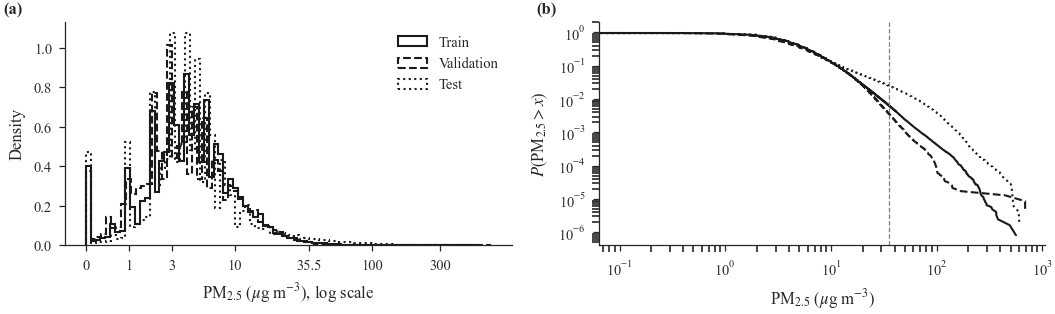

In [7]:
long = pd.DataFrame({'pm': pm_obs.values.ravel(), 'split': np.repeat(split.values, N)}).dropna()
q = long.groupby('split').pm.describe(percentiles=[.25, .5, .75, .9, .99, .999]).reindex(SPLITS)
q['share > 35.5'] = long.groupby('split').pm.apply(lambda v: (v > HIGH).mean()).reindex(SPLITS)
q['share < 1'] = long.groupby('split').pm.apply(lambda v: (v < 1).mean()).reindex(SPLITS)
display(q.round(3))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(COL2, 2.3))
for s in SPLITS:
    v = long.pm[long.split == s]
    c, ls = SPLIT_STYLE[s]
    a1.hist(np.log1p(v.clip(lower=0)), bins=80, density=True, histtype='step', lw=1.0,
            color=c, ls=ls, label=SPLIT_NAME[s])
    xs = np.sort(v.values)
    a2.plot(xs, 1 - np.arange(len(xs)) / len(xs), color=c, ls=ls, label=SPLIT_NAME[s])
ticks = np.array([0, 1, 3, 10, 35.5, 100, 300])
a1.set_xticks(np.log1p(ticks), [f'{t:g}' for t in ticks])
a1.set(xlabel=f'{PM_LABEL}, log scale', ylabel='Density'); a1.legend()
a2.set(xscale='log', yscale='log', xlabel=PM_LABEL, ylabel=r'$P$(PM$_{2.5} > x$)')
a2.axvline(HIGH, color='0.5', ls='--', lw=0.6)
panel_labels([a1, a2])
plt.tight_layout(); savefig('04_distribution_by_split'); plt.show()

## 5. Temporal patterns

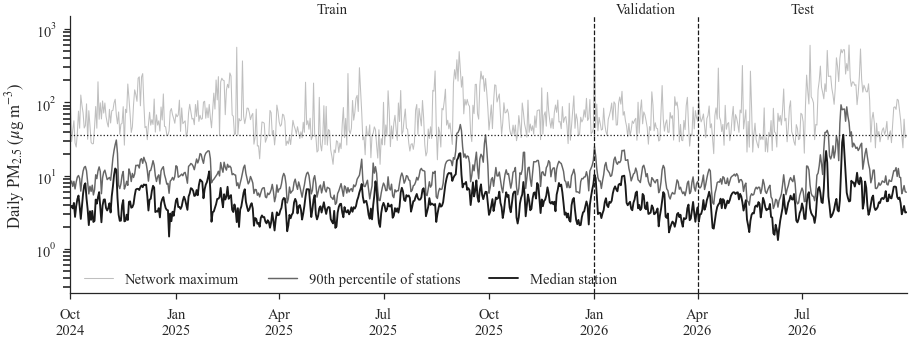

,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
pm_mean,4.93,6.28,5.94,7.53,5.74,3.82,4.38,3.76,4.91,4.82,6.40,11.53,5.51,6.31,5.16,7.51,4.88,3.85,4.60,4.50,3.71,8.13,15.27,5.30
pm_p99,20.70,33.00,26.74,33.00,28.92,18.50,17.00,13.00,20.70,16.80,23.40,68.30,25.40,27.00,24.60,33.00,22.00,20.00,18.00,15.00,14.00,60.00,123.00,18.30
station_hours_gt35.5,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.03,0.11,0.00
hours_any_gt35.5,0.21,0.39,0.26,0.45,0.43,0.13,0.08,0.03,0.18,0.10,0.24,0.82,0.33,0.28,0.25,0.39,0.17,0.14,0.12,0.09,0.09,0.62,0.91,0.12


In [8]:
net = pm_obs.median(axis=1).resample('D').mean()
p90 = pm_obs.quantile(0.9, axis=1).resample('D').mean()
mx = pm_obs.max(axis=1).resample('D').max()
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(COL2, 2.4))
ax.plot(mx.index, mx, color='0.75', lw=0.5, label='Network maximum')
ax.plot(p90.index, p90, color='0.4', lw=0.7, label='90th percentile of stations')
ax.plot(net.index, net, color='k', lw=0.9, label='Median station')
ax.axhline(HIGH, color='k', ls=':', lw=0.6)
for s in ['val', 'test']:                       # split boundaries, labelled at the top
    a = SPLITS[s][0]
    ax.axvline(a, color='k', lw=0.6, ls='--')
for s, (a, b) in SPLITS.items():
    ax.text(a + (b - a) / 2, 1.0, SPLIT_NAME[s], transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=7)
ax.set(yscale='log', ylabel=f'Daily {PM_LABEL}', xlim=(time[0], time[-1]), ylim=(0.25, 1500))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.legend(ncol=3, loc='lower left', bbox_to_anchor=(0, -0.02))
savefig('05_timeseries'); plt.show()
display(monthly.round(2).T)

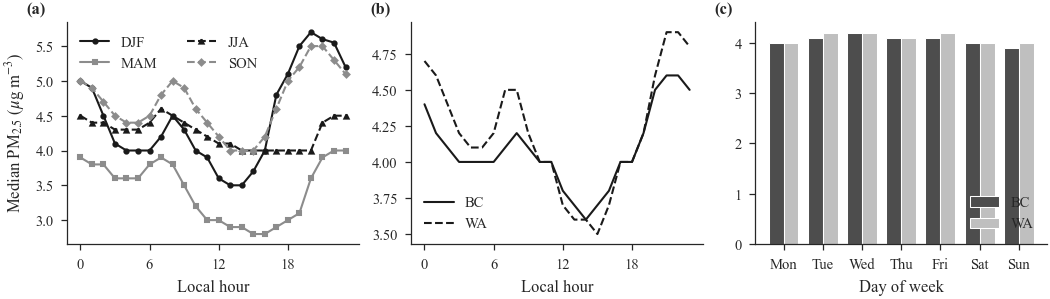

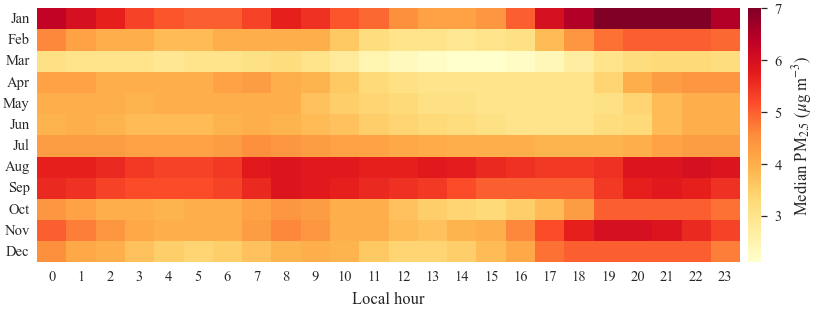

In [9]:
local = pm_obs.copy()
local.index = local.index.tz_convert('America/Vancouver')
st = local.stack().rename('pm').reset_index()
st.columns = ['time', 'node', 'pm']
st['hour'], st['dow'], st['month'] = st.time.dt.hour, st.time.dt.dayofweek, st.time.dt.month
st['season'] = st.month.map(SEASON)
st['region'] = st.node.map(sites.set_index('node').region)

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.2))
by_season = st.groupby(['season', 'hour']).pm.median().unstack(0)
for s, (c, ls, mk) in SEASON_STYLE.items():
    axes[0].plot(by_season.index, by_season[s], color=c, ls=ls, marker=mk, ms=2, label=s)
axes[0].set(xlabel='Local hour', ylabel=f'Median {PM_LABEL}', xticks=range(0, 24, 6))
axes[0].legend(ncol=2)
by_region = st.groupby(['region', 'hour']).pm.median().unstack(0)
for r, ls in [('BC', '-'), ('WA', '--')]:
    axes[1].plot(by_region.index, by_region[r], color='k', ls=ls, label=r)
axes[1].set(xlabel='Local hour', xticks=range(0, 24, 6)); axes[1].legend()
by_dow = st.groupby(['dow', 'region']).pm.median().unstack()
w = 0.38
axes[2].bar(np.arange(7) - w / 2, by_dow['BC'], w, color='0.3', label='BC')
axes[2].bar(np.arange(7) + w / 2, by_dow['WA'], w, color='0.75', label='WA')
axes[2].set_xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[2].set(xlabel='Day of week'); axes[2].legend(loc='lower right')
panel_labels(axes)
plt.tight_layout(); savefig('06_cycles'); plt.show()

hm = st.pivot_table(index='month', columns='hour', values='pm', aggfunc='median')
fig, ax = plt.subplots(figsize=(COL2, 2.2))
sns.heatmap(hm, cmap='YlOrRd', ax=ax, cbar_kws={'label': f'Median {PM_LABEL}', 'pad': 0.01})
ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.set(xlabel='Local hour', ylabel='')
ax.tick_params(length=0)
savefig('07_month_hour'); plt.show()

## 6. High-pollution episodes
A day is listed when many stations exceed 35.5 µg/m³ at the same time. These episodes are what CSI-style metrics and peak errors are sensitive to.

,stations_hit,station_hours_gt35,max_pm,median_pm,split
2026-08-06 00:00:00+00:00,87,1395,521.200012,36.799999,test
2026-08-05 00:00:00+00:00,82,1162,472.399994,28.799999,test
2026-08-07 00:00:00+00:00,56,840,520.000000,20.000000,test
2026-08-04 00:00:00+00:00,52,764,527.500000,10.000000,test
2025-09-06 00:00:00+00:00,48,725,279.000000,19.700001,train
2026-08-09 00:00:00+00:00,32,540,338.000000,5.700000,test
2025-09-05 00:00:00+00:00,47,509,491.399994,20.400000,train
2026-08-08 00:00:00+00:00,34,492,243.000000,9.800000,test
2026-08-10 00:00:00+00:00,29,411,269.799988,5.000000,test
2026-08-03 00:00:00+00:00,40,403,399.000000,4.000000,test


21 episodes with >= 10 stations above 35.5 on the same day


,start,days,peak_stations,max_pm,split
0,2024-11-09,2,19,110.199997,train
1,2024-12-02,1,11,222.399994,train
2,2025-01-01,1,11,69.500000,train
3,2025-01-19,1,14,64.300003,train
4,2025-01-22,2,13,66.599998,train
5,2025-01-26,6,20,103.500000,train
6,2025-02-07,1,11,224.199997,train
7,2025-02-12,1,10,197.800003,train
8,2025-06-12,1,14,73.300003,train
9,2025-07-05,1,13,143.800003,train


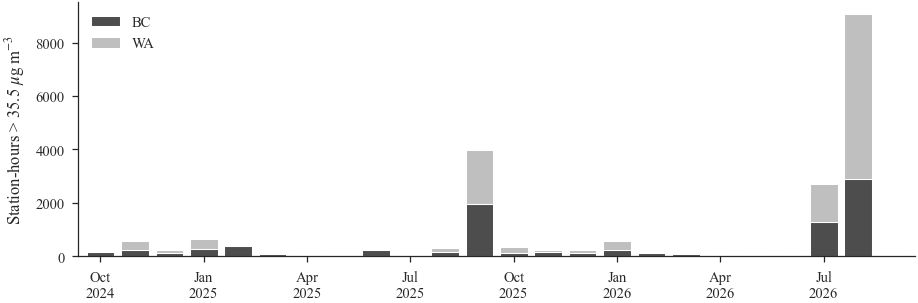

In [10]:
hi = (pm_obs > HIGH)
day = pd.DataFrame({
    'stations_hit': hi.resample('D').max().sum(axis=1),
    'station_hours_gt35': hi.resample('D').sum().sum(axis=1),
    'max_pm': pm_obs.resample('D').max().max(axis=1).round(1),
    'median_pm': pm_obs.resample('D').median().median(axis=1).round(1),
})
day['split'] = split.resample('D').first()
display(day.sort_values('station_hours_gt35', ascending=False).head(15))

ep = (day.stations_hit >= 10)
runs = (ep != ep.shift()).cumsum()[ep]
episodes = day[ep].groupby(runs).agg(start=('stations_hit', lambda s: s.index[0].date()),
                                     days=('stations_hit', 'size'), peak_stations=('stations_hit', 'max'),
                                     max_pm=('max_pm', 'max'), split=('split', 'first'))
print(f'{len(episodes)} episodes with >= 10 stations above 35.5 on the same day')
display(episodes.reset_index(drop=True))

reg = sites.set_index('node').region
by = hi.T.groupby(reg).sum().T.resample('MS').sum()
by.index = by.index.strftime('%b\n%Y')
fig, ax = plt.subplots(figsize=(COL2, 2.2))
by[['BC', 'WA']].plot.bar(stacked=True, ax=ax, color=['0.3', '0.75'], width=0.8, rot=0)
ax.set(xlabel='', ylabel=f'Station-hours > 35.5 {PM_UNIT}')
ax.set_xticks(range(0, len(by), 3), by.index[::3])
ax.legend(loc='upper left')
savefig('08_exceedances_by_month'); plt.show()

## 7. Temporal dependence and a persistence reference
The ACF shows how much of the 24 h history (`hist_len`) carries information about the next hours. Persistence (repeat the last input hour across all 24 forecast hours) is the bar every model should beat. It is computed here on the test split, scoring measured targets only, as `benchmark.py` does.

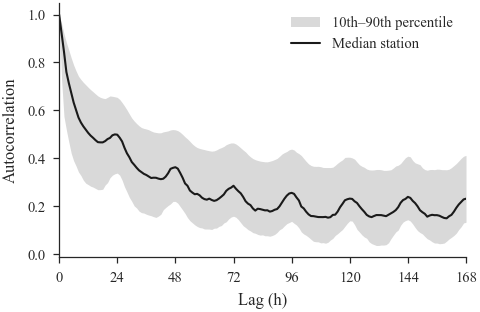

median ACF at lag 1/6/12/24/48 h: [0.924 0.633 0.506 0.498 0.362]


In [11]:
def acf(x, max_lag):
    x = x - np.nanmean(x)
    out = []
    for k in range(max_lag + 1):
        a, b = x[:len(x) - k], x[k:]
        m = ~np.isnan(a) & ~np.isnan(b)
        out.append(np.corrcoef(a[m], b[m])[0, 1])
    return np.array(out)

lags = 168
acfs = np.array([acf(np.log1p(pm_obs.iloc[:, j].clip(lower=0).values), lags) for j in range(N)])
fig, ax = plt.subplots(figsize=(COL1, 2.2))
ax.fill_between(range(lags + 1), *np.percentile(acfs, [10, 90], axis=0), color='0.85', lw=0,
                label='10th–90th percentile')
ax.plot(np.median(acfs, axis=0), color='k', label='Median station')
ax.set(xlabel='Lag (h)', ylabel='Autocorrelation', xlim=(0, lags), xticks=[0, 24, 48, 72, 96, 120, 144, 168])
ax.legend(); savefig('09_acf'); plt.show()
print('median ACF at lag 1/6/12/24/48 h:', np.round(np.median(acfs, axis=0)[[1, 6, 12, 24, 48]], 3))

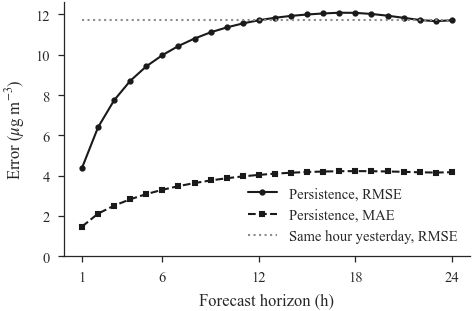

persistence averaged over 24 h: RMSE 10.69, MAE 3.67


,persistence_RMSE,persistence_MAE,yesterday_RMSE
horizon_h,,,
1,4.38,1.47,11.71
3,7.74,2.51,11.71
6,9.98,3.29,11.71
12,11.72,4.04,11.71
24,11.71,4.17,11.71


In [12]:
H = 24
y_in, y_obs = pm.values, pm_obs.values
target_idx = np.where(split.values == 'test')[0]     # every test hour is a forecast target
rows = []
for h in range(1, H + 1):
    pred = y_in[target_idx - h]                         # persistence: last (gap-filled) input hour
    pred24 = y_in[target_idx - 24]                      # same hour yesterday
    tgt = y_obs[target_idx]
    m = ~np.isnan(tgt)
    e, e24 = (pred - tgt)[m], (pred24 - tgt)[m]
    rows.append({'horizon_h': h, 'persistence_RMSE': np.sqrt(np.mean(e ** 2)), 'persistence_MAE': np.abs(e).mean(),
                 'yesterday_RMSE': np.sqrt(np.mean(e24 ** 2))})
pers = pd.DataFrame(rows).set_index('horizon_h')
fig, ax = plt.subplots(figsize=(COL1, 2.2))
ax.plot(pers.index, pers.persistence_RMSE, 'k-o', ms=2, label='Persistence, RMSE')
ax.plot(pers.index, pers.persistence_MAE, 'k--s', ms=2, label='Persistence, MAE')
ax.plot(pers.index, pers.yesterday_RMSE, color='0.55', ls=':', label='Same hour yesterday, RMSE')
ax.set(xlabel='Forecast horizon (h)', ylabel=f'Error ({PM_UNIT})', xticks=[1, 6, 12, 18, 24], ylim=(0, None))
ax.legend(loc='lower right')
savefig('10_persistence'); plt.show()
print(f"persistence averaged over 24 h: RMSE {pers.persistence_RMSE.mean():.2f}, MAE {pers.persistence_MAE.mean():.2f}")
pers.iloc[[0, 2, 5, 11, 23]].round(2)

## 8. Spatial dependence
How quickly correlation between stations falls off with distance shows how much a station graph can contribute. The graph links each station to `k_neighbors = 5` neighbours.

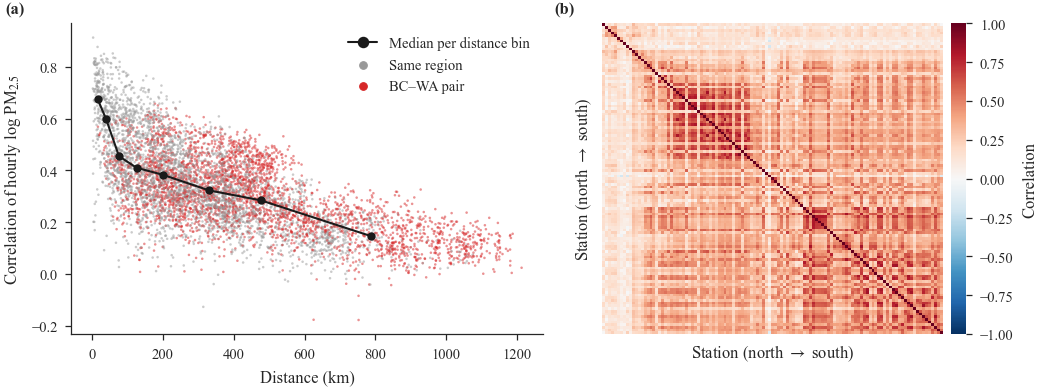

,count,25%,50%,75%
bin,,,,
"(0, 25]",134.0,0.562,0.676,0.746
"(25, 50]",177.0,0.466,0.597,0.677
"(50, 100]",459.0,0.363,0.455,0.595
"(100, 150]",505.0,0.322,0.410,0.535
"(150, 250]",1203.0,0.299,0.383,0.484
"(250, 400]",1521.0,0.256,0.323,0.406
"(400, 600]",1343.0,0.214,0.285,0.372
"(600, 1200]",1212.0,0.096,0.147,0.199


median correlation with each station's 5 graph neighbours: 0.59


In [13]:
logpm = np.log1p(pm_obs.clip(lower=0))
C = logpm.corr(min_periods=500).values
iu = np.triu_indices(N, 1)
pair = pd.DataFrame({'dist': D[iu], 'corr': C[iu],
                     'same_region': (sites.region.values[iu[0]] == sites.region.values[iu[1]])}).dropna()
pair['bin'] = pd.cut(pair.dist, [0, 25, 50, 100, 150, 250, 400, 600, 1200])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(COL2, 2.8), gridspec_kw={'width_ratios': [1.15, 1]})
a1.scatter(pair.dist, pair['corr'], s=1.5, lw=0, alpha=0.5, rasterized=True,
           c=np.where(pair.same_region, '0.6', 'tab:red'))
med = pair.groupby('bin', observed=True).agg(d=('dist', 'median'), c=('corr', 'median'))
a1.plot(med.d, med.c, 'k-o', ms=3, label='Median per distance bin')
a1.scatter([], [], s=6, c='0.6', label='Same region'); a1.scatter([], [], s=6, c='tab:red', label='BC–WA pair')
a1.set(xlabel='Distance (km)', ylabel='Correlation of hourly log PM$_{2.5}$')
a1.legend(loc='upper right', markerscale=1.5)
o = np.lexsort((lon, -lat))
sns.heatmap(C[np.ix_(o, o)], cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=a2, xticklabels=False,
            yticklabels=False, rasterized=True, cbar_kws={'label': 'Correlation', 'pad': 0.02})
a2.set(xlabel=r'Station (north $\rightarrow$ south)', ylabel=r'Station (north $\rightarrow$ south)')
panel_labels([a1, a2], names=None)
plt.tight_layout(); savefig('11_spatial_correlation'); plt.show()
display(pair.groupby('bin', observed=True)['corr'].describe()[['count', '25%', '50%', '75%']].round(3))

nbr = np.argsort(D, axis=1)[:, 1:6]
print('median correlation with each station\'s 5 graph neighbours:',
      round(float(np.nanmedian(C[np.arange(N)[:, None], nbr])), 3))

## 9. Weather and PM2.5
Weather is ERA5 reanalysis at each station's 0.25° cell. The relationships below are pooled over stations and hours, so they are associations, not causes. In summer, smoke dominates and the usual winter relationships (stagnant air, low wind, high humidity) can reverse.

,temperature,relative_humidity,rain,wind_speed10
season,,,,
DJF,-0.250000,0.029000,-0.264000,-0.338000
MAM,0.046000,0.006000,-0.204000,-0.258000
JJA,0.214000,-0.134000,-0.189000,-0.167000
SON,0.116000,-0.085000,-0.238000,-0.246000


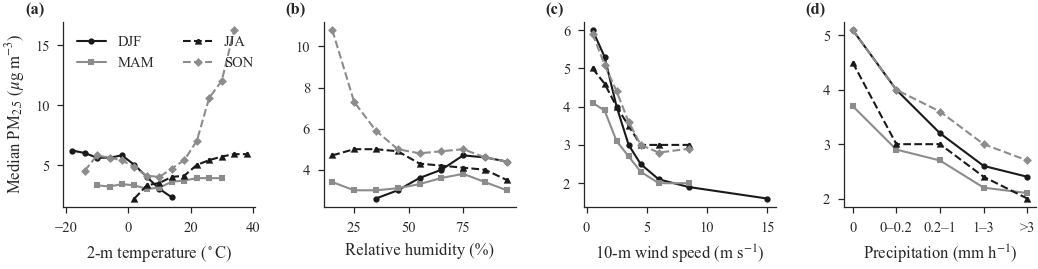

In [14]:
W = pd.DataFrame({f: met[f].values.ravel() for f in FEATURES[:5]})
W['pm'] = pm_obs.values.ravel()
W['season'] = np.repeat(time.month.map(SEASON).values, N)
W = W.dropna()
spear = W.groupby('season')[FEATURES[:4] + ['pm']].corr(method='spearman')['pm'].unstack()[FEATURES[:4]]
display(spear.reindex(['DJF', 'MAM', 'JJA', 'SON']).round(3).style.background_gradient(cmap='vlag', vmin=-.5, vmax=.5)
        .set_caption('Spearman correlation with PM2.5, by season'))

XLAB = {'temperature': r'2-m temperature ($^\circ$C)', 'relative_humidity': 'Relative humidity (%)',
        'wind_speed10': r'10-m wind speed (m s$^{-1}$)'}
fig, axes = plt.subplots(1, 4, figsize=(COL2, 2.0), sharey=False)
for ax, f, bins in zip(axes, ['temperature', 'relative_humidity', 'wind_speed10'],
                       [np.arange(-20, 41, 4), np.arange(10, 101, 10), [0, 1, 2, 3, 4, 5, 7, 10, 20]]):
    b = pd.cut(W[f], bins)
    g = W.groupby([b, 'season'], observed=True).pm.median().unstack()
    n = W.groupby([b, 'season'], observed=True).size().unstack()
    g = g.where(n >= 500)                                  # hide sparsely populated bins
    g.index = [iv.mid for iv in g.index]                   # plot at bin centres
    for s, (c, ls, mk) in SEASON_STYLE.items():
        ax.plot(g.index, g[s], color=c, ls=ls, marker=mk, ms=2, label=s)
    ax.set(xlabel=XLAB[f])
axes[0].set_ylabel(f'Median {PM_LABEL}')
axes[0].legend(ncol=2, loc='upper left')
rain_bin = pd.cut(W.rain, [-np.inf, 0, 0.2, 1, 3, np.inf], labels=['0', '0–0.2', '0.2–1', '1–3', '>3'])
g = W.groupby([rain_bin, 'season'], observed=True).pm.median().unstack()
for s, (c, ls, mk) in SEASON_STYLE.items():
    axes[3].plot(range(len(g)), g[s], color=c, ls=ls, marker=mk, ms=2)
axes[3].set_xticks(range(len(g)), g.index)
axes[3].set(xlabel=r'Precipitation (mm h$^{-1}$)')
panel_labels(axes, x=-0.2)
plt.tight_layout(); savefig('12_weather_relations'); plt.show()

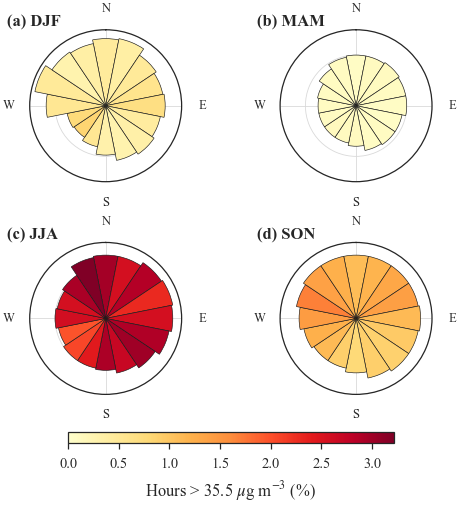

bar length = median PM2.5, rings every 2 ug/m3 (0-6); colour = share of hours above 35.5 ug/m3


,temperature,relative_humidity,rain,wind_speed10
train,9.31,75.320000,0.17,2.13
val,3.87,80.879997,0.21,2.22
test,15.46,64.500000,0.07,2.04


In [15]:
sector = ((W.wind_direction10 + 11.25) % 360 // 22.5).astype(int)
rose = W.groupby([W.season, sector]).pm.agg(['median', lambda v: (v > HIGH).mean()])
rose.columns = ['median', 'p_high']
fig, axes = plt.subplots(2, 2, figsize=(COL1, 4.1), subplot_kw={'projection': 'polar'})
axes = axes.ravel()
theta = np.radians(np.arange(16) * 22.5)
norm = plt.Normalize(0, 100 * rose.p_high.max())
rmax = np.ceil(rose['median'].max())
for ax, s in zip(axes, ['DJF', 'MAM', 'JJA', 'SON']):
    r = rose.loc[s].reindex(range(16))
    ax.bar(theta, r['median'], width=np.radians(22.5), color=plt.cm.YlOrRd(norm(100 * r['p_high'])),
           edgecolor='k', lw=0.3)
    ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
    ax.set_xticks(np.radians([0, 90, 180, 270]), ['N', 'E', 'S', 'W'])
    ax.grid(True, lw=0.4, color='0.85')           # a polar plot needs its rings to be readable
    ax.tick_params(labelsize=6, pad=0)
    ax.set_ylim(0, rmax)
    ax.set_yticks(np.arange(2, rmax + 0.1, 2))
    ax.set_yticklabels([])                       # ring spacing is given in the caption
fig.subplots_adjust(wspace=0.6, hspace=0.4)
panel_labels(axes, x=-0.15, y=1.0, names=['DJF', 'MAM', 'JJA', 'SON'])
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='YlOrRd'), ax=axes, shrink=0.8, pad=0.08, orientation='horizontal', aspect=30,
                  label=f'Hours > 35.5 {PM_UNIT} (%)')
cb.outline.set_linewidth(0.6)
savefig('13_wind_rose'); plt.show()
print(f'bar length = median PM2.5, rings every 2 ug/m3 (0-{rmax:g}); colour = share of hours above 35.5 ug/m3')

# weather shift between splits (models see these as inputs)
ws = pd.DataFrame({f: met[f].groupby(split).apply(lambda d: d.values.mean()) for f in FEATURES[:4]}).reindex(SPLITS)
ws.round(2)

## 10. Summary
_Written from the outputs above (dataset build of 2026-10-06). Re-check the numbers if the dataset is rebuilt._

**Network.** 115 stations: dense around Metro Vancouver, Puget Sound and Spokane, sparse in northern BC. The median distance to the nearest station is 26.5 km. The 5th-nearest neighbour, which the `k_neighbors = 5` graph links to, has a median distance of 64 km and a maximum of 393 km, so a few northern BC stations are linked to distant neighbours.

**Missing data.** Measured shares are 96.6 % (train), 93.4 % (val) and 95.9 % (test). 85 % of the 7,047 gaps are ≤ 6 h, but they hold only 12 % of missing hours; most missing hours sit in long outages filled from neighbouring stations. Filled values look like measured ones but with a lighter tail (99th pct 32 vs 37 µg/m³). This is why scoring uses measured values only.

**Distribution and split shift.** PM2.5 is heavily right-skewed (median 4 µg/m³). The **test split has a much heavier tail than train or val**: 99th pct 64 vs 30 (train) and 27 (val) µg/m³, and 2.5 % of measured hours above 35.5 vs 0.6 % and 0.4 %. 6–9 % of measured hours are below 1 µg/m³, which inflates MAPE.

**Episodes.**
- **Summer smoke 2026 (test):** from 20 Jul to late Aug 2026 at least 10 stations exceeded 35.5 on the same day for 40 straight days. The peak was 87 stations and 1,395 station-hours above 35.5 on 6 Aug. That is larger than any train-period day (max 725 station-hours, Sep 2025 smoke).
- **Winter episodes (train/val):** shorter, Nov–Feb, probably inversions and wood smoke.
- **1 Jan 2026 (val):** the dataset maximum, 687 µg/m³, with 25 stations above 35.5. This is likely New Year's Eve fireworks.

**Cycles.** Diurnal cycle in local time: lowest in mid-afternoon (14–15 h), highest in the evening (20–22 h), with a small morning peak around 07–08 h. This is strongest in winter and autumn, and the same in BC and WA. The day-of-week cycle is negligible.

**Temporal dependence.** Median ACF of log PM2.5: 0.92 at 1 h, 0.63 at 6 h, 0.51 at 12 h, 0.50 at 24 h (raised by the daily cycle), 0.36 at 48 h. Persistence on test: RMSE 4.4 at 1 h, rising to ≈ 11.7 µg/m³ from 12 h on; averaged over the 24 h horizon, RMSE 10.7 and MAE 3.7. Copying the same hour from the previous day has RMSE 11.7, no better than persistence beyond 12 h.

**Spatial dependence.** Median correlation between stations is 0.68 within 25 km, 0.46 at 50–100 km, 0.38 at 150–250 km and 0.15 beyond 600 km. The median correlation with a station's 5 graph neighbours is 0.59, so neighbours carry useful but far from complete information.

**Weather.**
- Wind speed and rain are negatively associated with PM2.5 in every season (Spearman down to −0.34 and −0.26 in winter).
- Temperature switches sign: negative in winter (−0.25, cold stagnant air) and positive in summer (+0.21).
- In autumn, very hot and very dry hours have high PM2.5, consistent with the Sep 2025 smoke.
- Test-period weather is warmer and drier than train (mean 15.5 vs 9.3 °C; RH 64.5 vs 75.3 %).

**Implications for the benchmark**
1. Test scores will be dominated by the Jul–Aug 2026 smoke period, which is more extreme than anything in train. Report errors for smoke and non-smoke periods separately, plus an exceedance metric, alongside overall RMSE/MAE.
2. Validation (Jan–Mar) contains no smoke, so early stopping and model selection on val favour winter behaviour.
3. Persistence (24 h average RMSE 10.7 / MAE 3.7 on measured test values) is the bar to beat; gains should be largest at 6–24 h, where persistence is weakest.